In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/satellite-image-classification/data/cloudy/train_17406.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_28684.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_33597.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_34079.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_30586.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_18281.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_33296.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_34303.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_1336.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_30792.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_19000.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_13047.jpg
/kaggle/input/satellite-image-classification/data/cloudy/train_21750.jpg
/kaggle/input/satellite-image-classification/data/cl

In [2]:
!pip install ftfy regex tqdm git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ppt4p0zi
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ppt4p0zi
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 

In [3]:
# Cell 0 (imports)
import os
import random
import clip
import torch
import numpy as np
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [4]:
# Cell 1
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

RND_SEED = 42
random.seed(RND_SEED)
np.random.seed(RND_SEED)
torch.manual_seed(RND_SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(RND_SEED)


Device: cuda


In [5]:
# Cell 2
# Provide your dataset root path (folder with subfolders cloudy, desert, green_area, water)
DATA_ROOT = "/kaggle/input/satellite-image-classification/data"

# Load CLIP once here to get preprocess transform (do not repeatedly call clip.load)
_clip_model_tmp, preprocess = clip.load("ViT-B/32", device=device)

class SatelliteDataset(Dataset):
    def __init__(self, root, preprocess):
        self.root = root
        self.preprocess = preprocess
        # classes are folder names (sorted)
        self.classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        self.images = []
        self.labels = []
        for i, cls in enumerate(self.classes):
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(("png","jpg","jpeg")):
                    self.images.append(os.path.join(folder, fname))
                    self.labels.append(i)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        img = Image.open(path).convert("RGB")
        img = self.preprocess(img)   # already a torch.Tensor
        label = self.labels[idx]
        return img, label


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 102MiB/s]


In [6]:
# Cell 3
full_dataset = SatelliteDataset(DATA_ROOT, preprocess)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

# split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n = len(full_dataset)
n_train = int(train_ratio * n)
n_val = int(val_ratio * n)
n_test = n - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(RND_SEED)
)

print(f"Split sizes — train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")


Classes: ['cloudy', 'desert', 'green_area', 'water']
Total images: 5631
Split sizes — train: 3941, val: 844, test: 846


In [7]:
# Cell 4
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [8]:
# Cell 5
class_prompts = {
    "cloudy": [
        "a satellite image of a cloudy region",
        "an aerial view covered with clouds",
        "a satellite photo showing heavy cloud cover",
        "a top-down image with dense clouds",
        "a satellite scene with scattered clouds",
        "an overhead view showing thick clouds",
        "a cloudy sky captured from space",
        "a satellite observation of cloudy weather",
        "aerial imagery showing cloud patches",
        "a satellite frame showing overcast conditions"
    ],
    "desert": [
        "a satellite image of a desert region",
        "an aerial view of sandy desert terrain",
        "a top-down satellite photo of dry desert land",
        "a satellite scene showing barren desert",
        "a satellite view of sand dunes",
        "aerial imagery of an arid desert landscape",
        "a desert area captured from space",
        "a satellite frame showing dry, sandy terrain",
        "an overhead image of vast desert land",
        "a satellite photo of a hot, dry desert"
    ],
    "green_area": [
        "a satellite image of green vegetation",
        "an aerial view of dense green forest",
        "a satellite photo showing lush green land",
        "a top-down view of agricultural green fields",
        "a satellite scene showing vegetation cover",
        "a satellite frame of forested area",
        "aerial imagery of green terrain",
        "a satellite view showing high vegetation density",
        "an overhead image of green landscape",
        "a satellite image of farming land with greenery"
    ],
    "water": [
        "a satellite image of a water body",
        "an aerial view of a river or lake",
        "a satellite photo of an ocean region",
        "a top-down view of blue water",
        "a satellite scene showing rivers and lakes",
        "a satellite frame capturing large water bodies",
        "aerial imagery of a coastline or sea",
        "a satellite image showing clear blue water",
        "an overhead view of aquatic regions",
        "a satellite photo showing water surfaces"
    ]
}

# Ensure keys match dataset classes
print("Dataset classes:", full_dataset.classes)
for cls in full_dataset.classes:
    if cls not in class_prompts:
        raise ValueError(f"No prompts provided for class '{cls}' — add prompts to class_prompts.")


Dataset classes: ['cloudy', 'desert', 'green_area', 'water']


In [9]:
# Cell 6
class CLIPWithHeads(nn.Module):
    def __init__(self, classes, class_prompts, num_classes, device="cuda"):
        super().__init__()
        self.classes = classes
        self.class_prompts = class_prompts
        self.device = device

        # Load CLIP once here (we already called clip.load earlier for preprocess)
        self.clip_model, _ = clip.load("ViT-B/32", device=device)
        # force fp32 to avoid dtype mismatch with adapter
        self.clip_model.float()

        embed_dim = self.clip_model.visual.output_dim  # 512

        # Freeze CLIP parameters
        for p in self.clip_model.parameters():
            p.requires_grad = False

        # Adapter (trainable)
        self.adapter = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

        # Classifier heads
        self.image_head = nn.Linear(embed_dim, num_classes)
        self.text_head  = nn.Linear(embed_dim, num_classes)

        # Trainable temperature (logit scale)
        self.logit_scale = nn.Parameter(torch.tensor(1.0))

    def encode_image(self, images):
        # images: tensor [B, C, H, W]
        with torch.no_grad():
            x = self.clip_model.encode_image(images)   # usually fp16 on GPU, but we forced float()
        x = x.float()
        x = self.adapter(x)   # adapter in fp32
        x = x / x.norm(dim=-1, keepdim=True)
        return x

    def encode_text(self, text_tokens):
        # text_tokens: tokenized batch
        with torch.no_grad():
            x = self.clip_model.encode_text(text_tokens)
        x = x.float()
        x = x / x.norm(dim=-1, keepdim=True)
        return x

    def prompt_batch_embeddings(self, class_ids):
        """
        Given a list/1D-tensor of class indices (length B), create a batch of prompts,
        tokenize once, and return text embeddings of shape [B, D].
        """
        prompts = []
        for cid in class_ids:
            cname = self.classes[int(cid)]
            prompt = random.choice(self.class_prompts[cname])
            prompts.append(prompt)
        tokens = clip.tokenize(prompts).to(self.device)   # batched tokenization
        return self.encode_text(tokens)


In [10]:
# Cell 7
num_classes = len(full_dataset.classes)
model = CLIPWithHeads(classes=full_dataset.classes, class_prompts=class_prompts, num_classes=num_classes, device=device).to(device)

# Train only adapter + heads + logit_scale
trainable = list(model.adapter.parameters()) + list(model.image_head.parameters()) + list(model.text_head.parameters()) + [model.logit_scale]
optimizer = optim.AdamW(trainable, lr=2e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


In [11]:
# Cell 8
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    losses = []
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        # image features
        img_feat = model.encode_image(images)        # [B, D]
        # text features (batched prompts matching labels)
        text_feat = model.prompt_batch_embeddings(labels)  # [B, D]

        scale = model.logit_scale.exp()
        logits_per_image = scale * img_feat @ text_feat.T   # [B, B]
        logits_per_text  = logits_per_image.T               # [B, B]
        targets = torch.arange(images.size(0), device=device)

        # contrastive loss (image->text and text->image)
        loss_i = F.cross_entropy(logits_per_image, targets)
        loss_t = F.cross_entropy(logits_per_text, targets)
        contrastive_loss = (loss_i + loss_t) / 2.0

        # classification heads (match each embedding to its label)
        img_logits = model.image_head(img_feat)   # [B, num_classes]
        text_logits = model.text_head(text_feat)  # [B, num_classes]
        ce_img = F.cross_entropy(img_logits, labels)
        ce_text = F.cross_entropy(text_logits, labels)
        classification_loss = (ce_img + ce_text) / 2.0

        loss = contrastive_loss + classification_loss
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return np.mean(losses)


def validate(model, loader, device):
    model.eval()
    losses = []
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            img_feat = model.encode_image(images)
            text_feat = model.prompt_batch_embeddings(labels)

            scale = model.logit_scale.exp()
            logits_per_image = scale * img_feat @ text_feat.T
            logits_per_text  = logits_per_image.T
            targets = torch.arange(images.size(0), device=device)

            loss_i = F.cross_entropy(logits_per_image, targets)
            loss_t = F.cross_entropy(logits_per_text, targets)
            contrastive_loss = (loss_i + loss_t) / 2.0

            img_logits = model.image_head(img_feat)
            text_logits = model.text_head(text_feat)
            ce_img = F.cross_entropy(img_logits, labels)
            ce_text = F.cross_entropy(text_logits, labels)
            classification_loss = (ce_img + ce_text) / 2.0

            loss = contrastive_loss + classification_loss
            losses.append(loss.item())

            preds = img_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = np.mean(losses)
    acc = 100.0 * (np.array(all_preds) == np.array(all_labels)).mean()
    return avg_loss, acc


In [12]:
# # Cell 9
# EPOCHS = 5
# best_val_acc = 0.0
# ckpt_path = "/kaggle/working/best_model.pt"

# for epoch in range(EPOCHS):
#     train_loss = train_one_epoch(model, train_loader, optimizer, device)
#     val_loss, val_acc = validate(model, val_loader, device)
#     scheduler.step()

#     print(f"Epoch {epoch+1}/{EPOCHS}  TrainLoss: {train_loss:.4f}  ValLoss: {val_loss:.4f}  ValAcc: {val_acc:.2f}%")

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save({
#             'epoch': epoch,
#             'model_state': model.state_dict(),
#             'optimizer_state': optimizer.state_dict(),
#             'val_acc': val_acc,
#             'classes': full_dataset.classes
#         }, ckpt_path)
#         print("Saved best model.")

# Cell 9 (Training Loop with History Logging)

EPOCHS = 5
best_val_acc = 0.0
ckpt_path = "/kaggle/working/best_model.pt"

# Initialize history lists for plotting the learning curves
train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, device)
    
    # Update scheduler
    scheduler.step()
    
    # Record history
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} TrainLoss: {train_loss:.4f} ValLoss: {val_loss:.4f} ValAcc: {val_acc:.2f}%")
    
    # Save the best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc': val_acc,
            'classes': full_dataset.classes
        }, ckpt_path)
        print("Saved best model.")


Epoch 1/5 TrainLoss: 4.2192 ValLoss: 3.9684 ValAcc: 99.17%
Saved best model.


Epoch 2/5 TrainLoss: 3.8758 ValLoss: 3.7514 ValAcc: 99.76%
Saved best model.


Epoch 3/5 TrainLoss: 3.7004 ValLoss: 3.6143 ValAcc: 99.88%
Saved best model.


Epoch 4/5 TrainLoss: 3.5793 ValLoss: 3.5114 ValAcc: 99.76%


Epoch 5/5 TrainLoss: 3.4952 ValLoss: 3.4411 ValAcc: 100.00%
Saved best model.


In [13]:
# Cell 10
ckpt = torch.load(
    "/kaggle/working/best_model.pt",
    map_location=device,
    weights_only=False   # ← REQUIRED for PyTorch 2.6+
)

model.load_state_dict(ckpt['model_state'])
model.to(device)
print("Loaded checkpoint — best val acc:", ckpt['val_acc'])

# Evaluate on test set: compute accuracy + classification report
def eval_and_report(loader, model, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device); labels = labels.to(device)
            feats = model.encode_image(images)
            logits = model.image_head(feats)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100.0 * (np.array(all_preds) == np.array(all_labels)).mean()
    print(f"Accuracy: {acc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = eval_and_report(test_loader, model, device, full_dataset.classes)


Loaded checkpoint — best val acc: 100.0
Accuracy: 99.88%

Classification Report:
              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       230
      desert       1.00      1.00      1.00       173
  green_area       1.00      1.00      1.00       224
       water       1.00      1.00      1.00       219

    accuracy                           1.00       846
   macro avg       1.00      1.00      1.00       846
weighted avg       1.00      1.00      1.00       846



<Figure size 700x700 with 0 Axes>

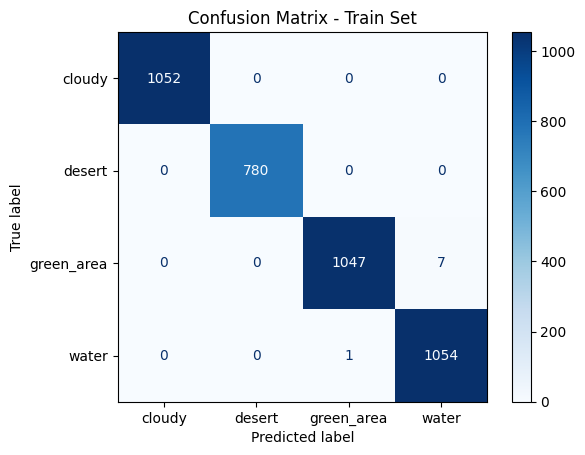

<Figure size 700x700 with 0 Axes>

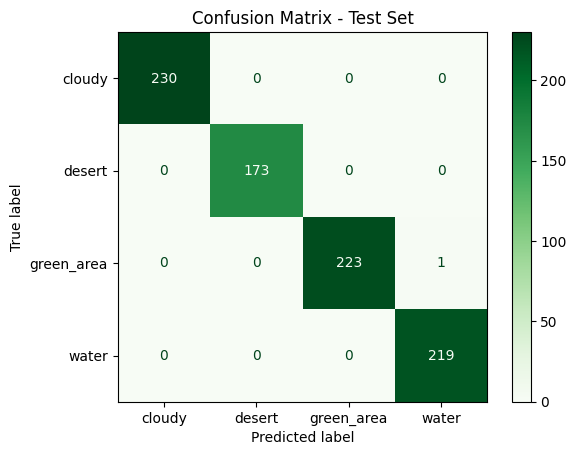

In [14]:
# Cell 11
# Confusion matrix for train set (use train_loader)
train_labels, train_preds = [], []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        feats = model.encode_image(images)
        logits = model.image_head(feats)
        preds = logits.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.numpy())

train_cm = confusion_matrix(train_labels, train_preds)
plt.figure(figsize=(7,7))
disp = ConfusionMatrixDisplay(train_cm, display_labels=full_dataset.classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Train Set")
plt.show()

# Confusion matrix for test set (we already computed y_true,y_pred)
test_cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,7))
disp = ConfusionMatrixDisplay(test_cm, display_labels=full_dataset.classes)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [15]:
# Cell 12
def predict_image(image_path, model, classes):
    img = Image.open(image_path).convert("RGB")
    img_t = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.encode_image(img_t)
        logits = model.image_head(feat)
        pred = logits.argmax(dim=1).item()

    return classes[pred]

# usage example:
# print(predict_image("/kaggle/input/.../cloudy/example.jpg", model, full_dataset.classes))


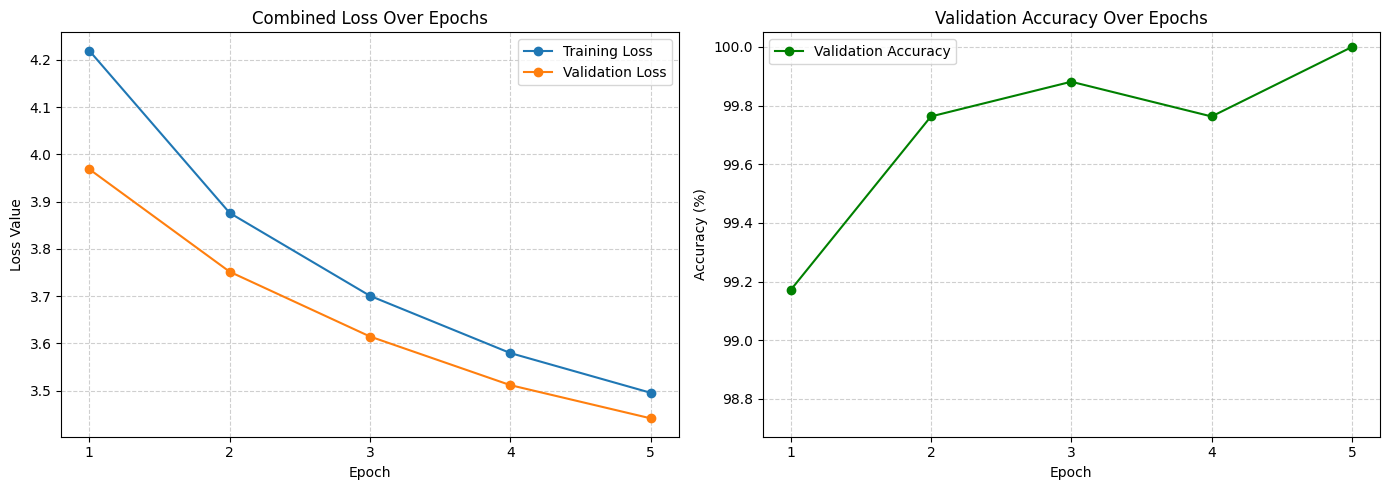

Loss curve saved to: /kaggle/working/loss_curve.png
Accuracy curve saved to: /kaggle/working/accuracy_curve.png


In [16]:
# Cell 12 (New Cell for Plotting)

epochs_range = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(14, 5))

# --- Loss Curve (Training and Validation) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss_history, label='Validation Loss', marker='o')
plt.title('Combined Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(epochs_range)
plt.savefig('/kaggle/working/loss_curve.png') # Save loss curve 

# --- Accuracy Curve (Validation) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy', color='green', marker='o')
plt.title('Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(min(val_acc_history) - 0.5, 100.05) # Adjust y-limit for better visualization of high accuracy
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(epochs_range)
plt.savefig('/kaggle/working/accuracy_curve.png') # Save accuracy curve 

plt.tight_layout()
plt.show()

print("Loss curve saved to: /kaggle/working/loss_curve.png")
print("Accuracy curve saved to: /kaggle/working/accuracy_curve.png")

In [17]:
# from IPython.display import FileLink
# FileLink('/kaggle/working/best_model.pt')


In [18]:
# # Cell 13 - Save model for download
# import shutil

# # The model is already saved at /kaggle/working/best_model.pt
# # Let's verify it exists
# if os.path.exists("/kaggle/working/best_model.pt"):
#     file_size = os.path.getsize("/kaggle/working/best_model.pt") / (1024 * 1024)  # MB
#     print(f"✅ Model saved successfully!")
#     print(f"📦 File: best_model.pt")
#     print(f"💾 Size: {file_size:.2f} MB")
#     print(f"📍 Location: /kaggle/working/best_model.pt")
#     print(f"\n🎯 Validation Accuracy: {ckpt['val_acc']:.2f}%")
#     print(f"📊 Classes: {ckpt['classes']}")
# else:
#     print("❌ Model file not found!")